In [ ]:
# ============================================================================
# RESEARCH PROJECT: Colorectal Histology Classification using Deep Learning
# ============================================================================
# This notebook implements a CNN-based classifier for colorectal histology images
# Dataset: TensorFlow Datasets - colorectal_histology
# Classes: 8 tissue types (tumor, stroma, complex, lympho, debris, mucosa, adipose, empty)
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from datetime import datetime

# Research project configuration
PROJECT_NAME = "colorectal_histology_classification"
EXPERIMENT_NAME = f"experiment_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

SAVE_DIR = "/content/drive/MyDrive/colorectal_model"
EXPERIMENT_DIR = os.path.join(SAVE_DIR, EXPERIMENT_NAME)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(EXPERIMENT_DIR, "custom_cnn_model.keras")
CHECKPOINT_DIR = os.path.join(EXPERIMENT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(EXPERIMENT_DIR, "results")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"📁 Experiment Directory: {EXPERIMENT_DIR}")
print(f"📁 Model will be saved to: {MODEL_PATH}")
print(f"📁 Checkpoints will be saved to: {CHECKPOINT_DIR}")
print(f"📁 Results will be saved to: {RESULTS_DIR}")


In [ ]:
# ============================================================================
# REPRODUCIBILITY SETUP
# ============================================================================
# Set random seeds for reproducibility in research
RANDOM_SEED = 42

import random
import numpy as np
import tensorflow as tf
import os

# Set Python random seed
random.seed(RANDOM_SEED)

# Set NumPy random seed
np.random.seed(RANDOM_SEED)

# Set TensorFlow random seed
tf.random.set_seed(RANDOM_SEED)

# Set environment variables for reproducibility
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Configure TensorFlow for reproducibility
tf.config.experimental.enable_op_determinism()

print(f"✅ Reproducibility configured with seed: {RANDOM_SEED}")
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ Deterministic operations enabled")


✅ Model saved to: /content/drive/MyDrive/colorectal_model/custom_cnn_model.keras


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    classification_report
)
from tensorflow.keras.utils import to_categorical

Data Extraction from Dataset

In [2]:
# Load the dataset
data, info = tfds.load('colorectal_histology', with_info=True)

# Print available splits
print(info.features)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.B7X4B4_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.
FeaturesDict({
    'filename': Text(shape=(), dtype=string),
    'image': Image(shape=(150, 150, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=8),
})


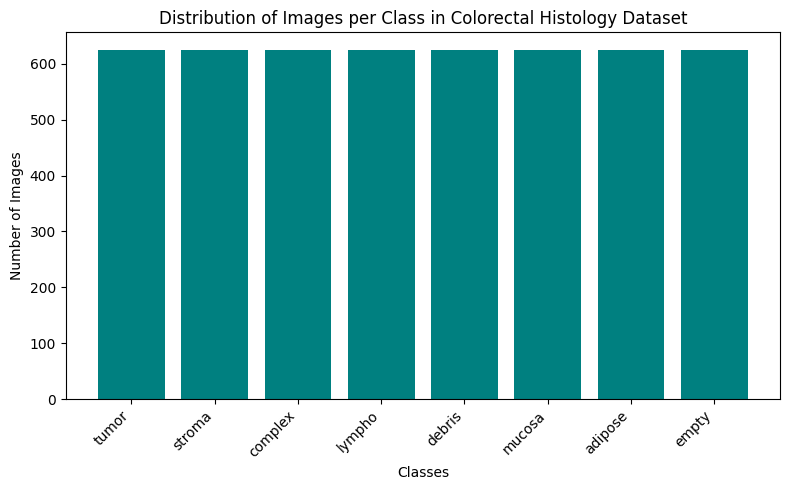

In [3]:
train_data = data['train']

# Extract label names
class_names = info.features['label'].names

# Count number of images per class
label_counts = {i: 0 for i in range(len(class_names))}

for sample in tfds.as_numpy(train_data):
    label_counts[sample['label']] += 1

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(len(class_names)), label_counts.values(), color='teal')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Colorectal Histology Dataset')
plt.tight_layout()
plt.show()

Data Augmentation

In [ ]:
# Data augmentation is implemented using tf.keras.Sequential layers
# in the preprocessing pipeline (see Cell 11)
# This approach is more efficient for tf.data pipelines


Load and Split Dataset

In [ ]:
# Load and split dataset: 70% train, 15% validation, 15% test
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'colorectal_histology',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],  # 70% train, 15% val, 15% test
    as_supervised=True,                   # (image, label)
    with_info=True
)


In [ ]:
IMG_SIZE = 224  # Consistent image size throughout
BATCH_SIZE = 8

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

def augment(image, label):
    image = data_augment(image)
    return image, label

# Apply augmentation only to training data
train_ds = ds_train.map(preprocess).map(augment).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Custom CNN model

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=8):
    # Use Input layer to avoid deprecation warning
    model = models.Sequential([
        Input(shape=input_shape),  # Explicit Input layer
        
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 5
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),  # Already flattens spatial dimensions

        # Classifier (no Flatten needed after GlobalAveragePooling2D)
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [ ]:
model = build_custom_cnn()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,  # Use validation set for monitoring
    epochs=50,
    callbacks=callbacks
)

# Save model after training
model.save(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.5553 - loss: 1.1857 - val_accuracy: 0.5400 - val_loss: 1.3556 - learning_rate: 1.0000e-04
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7066 - loss: 0.7706 - val_accuracy: 0.7870 - val_loss: 0.5469 - learning_rate: 1.0000e-04
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7342 - loss: 0.7022 - val_accuracy: 0.8250 - val_loss: 0.4793 - learning_rate: 1.0000e-04
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7495 - loss: 0.6478 - val_accuracy: 0.8430 - val_loss: 0.4128 - learning_rate: 1.0000e-04
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.8079 - loss: 0.5348 - val_accuracy: 0.7250 - val_loss: 0.6887 - learning_rate: 1.0000e-04
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 101ms/step - accuracy: 0.7962 - loss: 0.5261 - val_accuracy: 0.8470 - val_loss: 0.4162 - learning_rate: 1.0000e-04
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 10

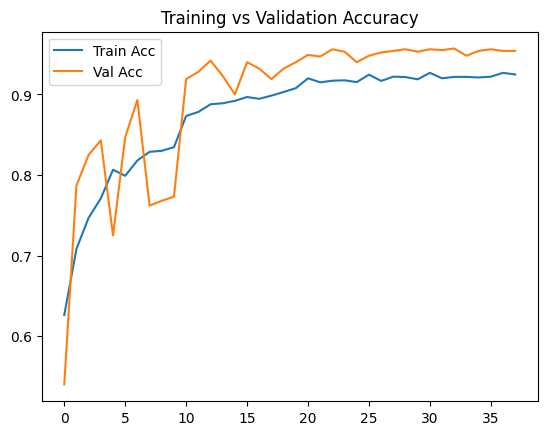

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━

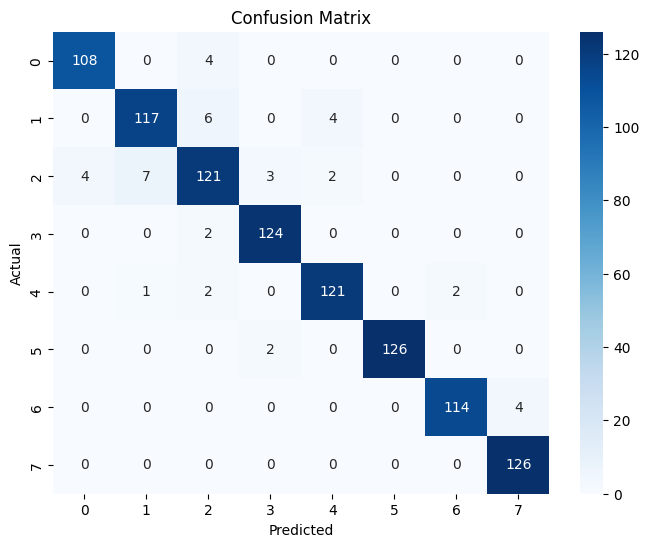

              precision    recall  f1-score   support

       tumor       0.96      0.96      0.96       112
      stroma       0.94      0.92      0.93       127
     complex       0.90      0.88      0.89       137
      lympho       0.96      0.98      0.97       126
      debris       0.95      0.96      0.96       126
      mucosa       1.00      0.98      0.99       128
     adipose       0.98      0.97      0.97       118
       empty       0.97      1.00      0.98       126

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [ ]:
# Efficient evaluation using batched predictions
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)

# Extract true labels efficiently
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=ds_info.features['label'].names,
            yticklabels=ds_info.features['label'].names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed metrics
print(classification_report(y_true, y_pred, target_names=ds_info.features['label'].names))


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


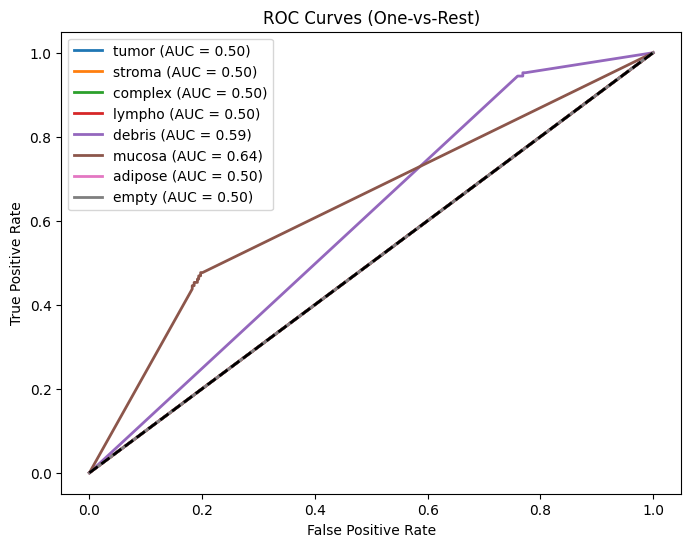

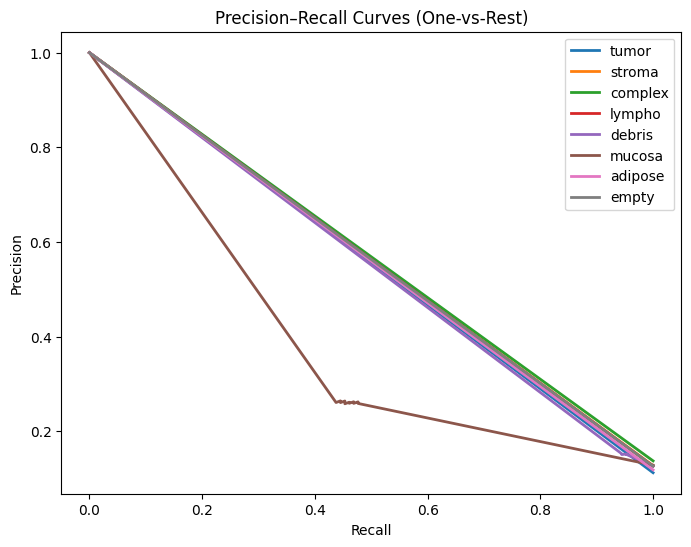

In [ ]:
# Use preprocessed test_ds and already computed predictions from Cell 16
# Extract true labels from preprocessed test dataset
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

# Use predictions from previous cell (y_pred_proba) or recompute if needed
if 'y_pred_proba' not in locals():
    y_pred_proba = model.predict(test_ds)

num_classes = y_pred_proba.shape[1]
class_names = ds_info.features['label'].names  # Use consistent variable name

# --- ROC Curves (One-vs-Rest) ---
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(to_categorical(y_true, num_classes)[:, i],
                            y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curves (One-vs-Rest) ---
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        to_categorical(y_true, num_classes)[:, i],
        y_pred_proba[:, i]
    )
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

XAI implementation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Class: 5
✅ Using last conv layer: conv2d_4


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_64']]
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


✅ Grad-CAM result saved as gradcam_result.png


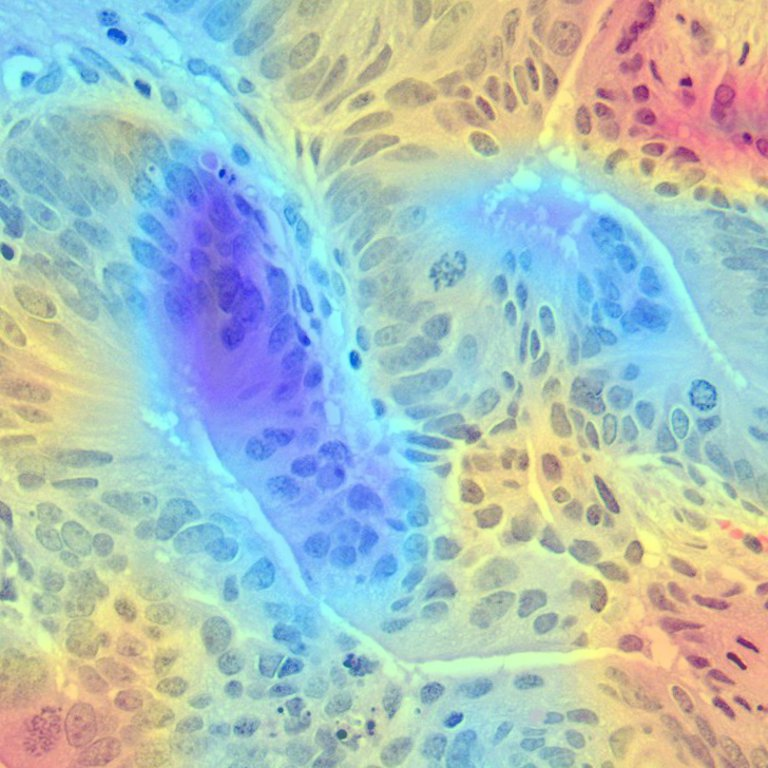

In [ ]:
import cv2
from tensorflow.keras.preprocessing import image

# -------------------------------
# 1️⃣ Load and preprocess the image (use IMG_SIZE = 224)
# -------------------------------
img_path = "/content/sample_test_image2.jpeg"  # Update path as needed
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0  # Normalize to [0, 1]

# -------------------------------
# 2️⃣ Make a prediction
# -------------------------------
preds = model.predict(x, verbose=0)
predicted_class = np.argmax(preds[0])
predicted_prob = preds[0][predicted_class]
class_names = ds_info.features['label'].names
print(f"Predicted Class: {predicted_class} ({class_names[predicted_class]})")
print(f"Confidence: {predicted_prob:.4f}")

# -------------------------------
# 3️⃣ Identify the last Conv2D layer
# -------------------------------
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("❌ No Conv2D layer found in model!")

print(f"✅ Using last conv layer: {last_conv_layer_name}")

# -------------------------------
# 4️⃣ Build Grad-CAM model using model's input directly
# -------------------------------
# Get the output of the last conv layer
last_conv_layer = model.get_layer(last_conv_layer_name)
grad_model = tf.keras.models.Model(
    inputs=[model.inputs],
    outputs=[last_conv_layer.output, model.output]
)

# -------------------------------
# 5️⃣ Compute Gradients (Grad-CAM)
# -------------------------------
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

# -------------------------------
# 6️⃣ Normalize heatmap
# -------------------------------
heatmap = np.maximum(heatmap.numpy(), 0)
heatmap /= np.max(heatmap)

# -------------------------------
# 7️⃣ Overlay Grad-CAM heatmap on image
# -------------------------------
img_original = cv2.imread(img_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original_resized = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))

heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

superimposed_img = cv2.addWeighted(img_original_resized, 0.6, heatmap_colored, 0.4, 0)

# Save result
cv2.imwrite("gradcam_result.png", cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR))
print("✅ Grad-CAM result saved as gradcam_result.png")

# Display using matplotlib (portable, not Colab-specific)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_original_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM: {class_names[predicted_class]}")
plt.axis("off")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3694658038.py:26: UserWarning: Glyph 129515 (\N{PETRI DISH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3694658038.py:26: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


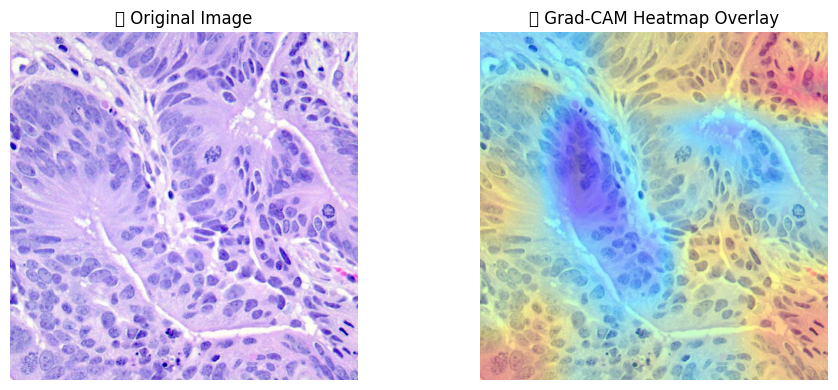


🎨 HEATMAP COLOR LEGEND:
🔵 Blue   → Low importance (model paid little attention)
🟡 Yellow → Moderate importance (some contribution)
🔴 Red    → High importance (model focused strongly here)



In [ ]:
# Display heatmap legend and explanation
print("\n" + "="*60)
print("HEATMAP COLOR LEGEND:")
print("="*60)
print("Blue   → Low importance (model paid little attention)")
print("Yellow → Moderate importance (some contribution)")
print("Red    → High importance (model focused strongly here)")
print("="*60)

In [ ]:
# Use dataset class names (already defined in previous cells)
label = ds_info.features['label'].names[predicted_class]
print(f"Predicted Class: {label}")
print(f"Class Index: {predicted_class}")

Predicted Class: mucosa


In [ ]:
import textwrap

# --- After your Grad-CAM visualization code, add this ---

# Mapping of class → explanation
tissue_explanations = {
    "mucosa": {
        "title": "NORMAL MUCOSAL TISSUE",
        "description": (
            "Healthy epithelial lining of the colon with normal glandular architecture "
            "and cellular organization."
        ),
        "meaning": [
            "Normal, healthy colon lining",
            "Proper glandular structure and organization",
            "No evidence of dysplasia or malignancy",
            "Functional absorptive and secretory tissue",
        ],
        "causes": [
            "Normal physiological tissue — no pathological cause",
            "Represents healthy baseline tissue",
            "Expected finding in normal colonoscopy biopsies",
        ],
        "clinical": [
            "Reassuring finding — no pathology detected",
            "Confirms absence of dysplasia or cancer in biopsied area",
            "Important baseline for future comparisons",
            "Indicates well-preserved tissue architecture",
        ],
        "treatment": {
            "treatable": "N/A — No treatment needed (healthy tissue)",
            "options": [
                "Continue routine screening colonoscopy per guidelines",
                "Maintain healthy lifestyle and diet",
                "High-fiber diet for colon health",
                "Regular exercise and healthy weight maintenance",
                "Limit red/processed meats, alcohol, and smoking cessation",
                "Adequate hydration and balanced nutrition",
            ],
            "prognosis": "Excellent — normal healthy tissue",
        },
        "recommendations": [
            "Age 45–50+: Screening colonoscopy every 10 years (if average risk)",
            "Family history: Earlier and more frequent screening",
            "Maintain healthy diet rich in fruits, vegetables, and whole grains",
            "Regular physical activity (≥150 min/week moderate exercise)",
            "Maintain healthy BMI",
            "Report new symptoms promptly (bleeding, pain, change in bowel habits)",
        ],
    },

    "tumor": {
        "title": "ADENOCARCINOMA / TUMOR TISSUE",
        "description": "Abnormal proliferation of epithelial cells forming irregular glands.",
        "meaning": [
            "Evidence of malignancy or pre-cancerous changes",
            "Loss of normal cellular polarity and gland structure",
            "Invasion into surrounding tissues possible",
        ],
        "causes": [
            "Genetic mutations in APC, KRAS, p53 pathways",
            "Chronic inflammation or adenomatous polyps",
        ],
        "clinical": [
            "Requires histopathological confirmation",
            "Guides further staging and treatment",
        ],
        "treatment": {
            "treatable": "Yes — with surgery, chemotherapy, and/or radiation depending on stage",
            "options": [
                "Surgical resection of affected segment",
                "Adjuvant chemotherapy (e.g., FOLFOX regimen)",
                "Targeted therapy for advanced stages",
            ],
            "prognosis": "Variable — depends on stage and differentiation",
        },
        "recommendations": [
            "Urgent referral to oncology specialist",
            "CT/MRI for staging workup",
            "Molecular profiling for targeted therapy eligibility",
        ],
    },

    # You can add similar structured entries for other classes:
    # "stroma", "complex", "lympho", "debris", "adipose", "empty"
}

# --- Generate Explanation ---
# Use dataset class names instead of hardcoded list
pred_label = ds_info.features['label'].names[predicted_class]
info = tissue_explanations.get(pred_label, None)

print("=" * 80)
print(f"📊 TISSUE CLASSIFICATION: {info['title'] if info else pred_label.upper()}")
print("=" * 80)
if info:
    print(f"\n📝 DESCRIPTION:\n   {info['description']}\n")

    print("🔍 WHAT THIS MEANS:")
    for line in info["meaning"]:
        print(f"   • {line}")

    print("\n🧬 POSSIBLE CAUSES / ASSOCIATIONS:")
    for line in info["causes"]:
        print(f"   • {line}")

    print("\n⚕️ CLINICAL SIGNIFICANCE:")
    for line in info["clinical"]:
        print(f"   • {line}")

    print("\n💊 TREATMENT INFORMATION:")
    print(f"   Is it treatable? {info['treatment']['treatable']}")
    print("\n   Treatment Options:")
    for line in info["treatment"]["options"]:
        print(f"   • {line}")
    print(f"\n   📈 Prognosis: {info['treatment']['prognosis']}")

    print("\n👨‍⚕️ RECOMMENDATIONS:")
    for line in info["recommendations"]:
        print(f"   • {line}")
else:
    print("No detailed explanation available for this class yet.\n")

print("\n" + "=" * 80)
print("⚠️ IMPORTANT DISCLAIMER:")
print("=" * 80)
print(textwrap.dedent("""
This AI-generated explanation is for EDUCATIONAL purposes only.
It is NOT a substitute for professional medical diagnosis or treatment.
Always consult qualified healthcare providers for:
  • Definitive diagnosis and treatment planning
  • Interpretation of pathology results
  • Personalized medical advice
  • Emergency or urgent medical concerns
"""))
print("=" * 80)


📊 TISSUE CLASSIFICATION: NORMAL MUCOSAL TISSUE

📝 DESCRIPTION:
   Healthy epithelial lining of the colon with normal glandular architecture and cellular organization.

🔍 WHAT THIS MEANS:
   • Normal, healthy colon lining
   • Proper glandular structure and organization
   • No evidence of dysplasia or malignancy
   • Functional absorptive and secretory tissue

🧬 POSSIBLE CAUSES / ASSOCIATIONS:
   • Normal physiological tissue — no pathological cause
   • Represents healthy baseline tissue
   • Expected finding in normal colonoscopy biopsies

⚕️ CLINICAL SIGNIFICANCE:
   • Reassuring finding — no pathology detected
   • Confirms absence of dysplasia or cancer in biopsied area
   • Important baseline for future comparisons
   • Indicates well-preserved tissue architecture

💊 TREATMENT INFORMATION:
   Is it treatable? N/A — No treatment needed (healthy tissue)

   Treatment Options:
   • Continue routine screening colonoscopy per guidelines
   • Maintain healthy lifestyle and diet
   • Hi